<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_04_beta_si3n4_multislice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Multislice Simulation of Graphene Boundary



We will:
1.  Define the crystal structure and convert the hexagonal unit cell to a larger **rectangular supercell** suitable for FFT-based multislice.
2.  Generate the projected potentials for the slices.
3.  Perform the multislice propagation loop.
4.  Visualize the exit wave and simulate TEM images at different defocus values.

References:
*   Kirkland, E. J. *Advanced Computing in Electron Microscopy*. (Figures 7.9 - 7.12)

## 1. Import Libraries and Parameters

We use `numpy` for calculations and `matplotlib` for display. 

**Simulation Parameters:**
*   Energy: 80 keV ($\lambda \approx 0.0251$ Å)
*   Lattice Constants Using the absolute dimensions ($120 \times 64$ Å) of  Grain Boundary model.
*   Pixel Size: $1024 \times 512$ pixels ($\Delta x \approx 0.11$ Å).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical Constants ---
h = 6.62607015e-34    # Planck's constant [J s]
m0 = 9.10938356e-31   # Electron rest mass [kg]
e = 1.602176634e-19   # Elementary charge [C]
c = 2.99792458e8      # Speed of light [m/s]

def get_wavelength_sigma(voltage_kv):
    """
    Calculates relativistic electron wavelength and interaction parameter.
    
    Args:
        voltage_kv (float): Accelerating voltage in kilovolts.
        
    Returns:
        tuple: (wavelength in Angstroms, sigma in rad/(V*m))
    """
    V = voltage_kv * 1000
    E0 = m0 * c**2
    
    # Lorentz factor (gamma): Accounts for relativistic mass increase
    # As voltage increases, electrons become "heavier" and wavelength shortens.
    gamma = 1 + (e * V) / E0
    
    # Relativistic De Broglie Wavelength: lambda = h / p
    # Formula: lambda = h / sqrt( 2*m0*e*V * (1 + eV/2m0c^2) )
    lam = h / (np.sqrt(2 * m0 * e * V * (1 + e * V / (2 * E0))))
    
    # Interaction parameter sigma (rad / V*m)
    # Determines the phase shift per volt of potential encountered by the wave.
    sigma = (2 * np.pi * m0 * e * lam) / (h**2) * gamma
    
    return lam * 1e10, sigma 

# ================= CRITICAL SETTING =================
# For Graphene, voltage is reduced from 200kV to 80kV 
# to stay below the knock-on damage threshold (~86kV).
voltage = 80.0 
# ====================================================

lam, sigma_SI = get_wavelength_sigma(voltage)

# Convert sigma to units compatible with Angstrom-scale grids [rad / (V * A)]
sigma = sigma_SI / 1e10 

print(f"Simulation Settings - Optimized for 2D Graphene:")
print(f"Accelerating Voltage: {voltage} kV")
print(f"Electron Wavelength:  {lam:.4f} Å")
print(f"Interaction Sigma:    {sigma:.4e} rad/(V·Å)")

ModuleNotFoundError: No module named 'numpy'

## 2. Atomic Modeling & Grid Discretization


*  This block handles the transition from a discrete list of atomic coordinates to a continuous numerical grid.


Found 1 files

File: grapheneGBexperiment_tM=47.156deg_tL=13.462deg_0913.xyz
Misorientation: 47.156
Atoms: (793, 3)
Atoms: [[80.370993  4.602998  0.      ]
 [80.558904  2.366084  0.      ]
 [79.806375  3.359316  0.      ]
 ...
 [84.229573 62.409889  0.      ]
 [82.203601 62.847464  0.      ]
 [83.0903   62.042271  0.      ]]


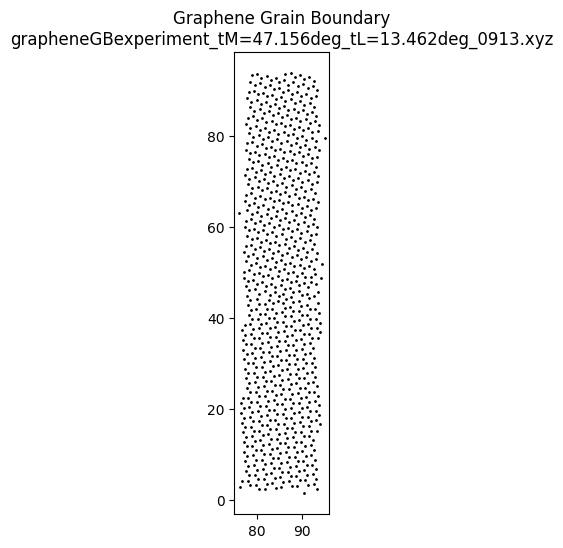

STATUS: Grid dimensions set to 512 x 2048 pixels.
Actual sampling: dx=0.0447 A, dy=0.0470 A


In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import re  # 补充了 re 库，用于 read_exp_gb_xyz 中的正则匹配

# =========================================================================
# STEP 1: INITIAL SETUP AND READING LOGIC (KEEP AS IS)
# =========================================================================

folder = r"C:\Users\XIA\Desktop\465\Project\MultiSlice\MultiSlice\MultiSlice_final_experiment" 
files = glob.glob(os.path.join(folder, "*.xyz"))
print(f"Found {len(files)} files")



def read_exp_gb_xyz(filename):

    # 1. Parse angles from filename
    
    m = re.search(r'tM=([\d.]+)deg_tL=([\d.]+)deg', filename)

    misorientation = float(m.group(1))
    line_angle = float(m.group(2))

    # 2. Read coordinates

    coords = []

    with open(filename) as f:
        lines = f.readlines()

    for line in lines:

        parts = line.split()

        # coordinate lines have exactly 3 numbers
        if len(parts) == 3:

            try:
                x, y, z = map(float, parts)
                coords.append([x, y, z])
            except:
                pass

    coords = np.array(coords)

    return misorientation, line_angle, coords


# Loop through files (change gb/exp_gb as needed)
for file in files:

    mis, angle, atoms = read_exp_gb_xyz(file)
    coords=atoms
    
    print(f"\nFile: {os.path.basename(file)}")
    print("Misorientation:", mis)
    print("Atoms:", atoms.shape)
    print("Atoms:", atoms)
    offset = 55

    plt.figure(figsize=(6,6))
    plt.scatter(atoms[:,0], atoms[:,1], s=1, c='k')
    plt.gca().set_aspect('equal', adjustable='box')



    plt.title(f"Graphene Grain Boundary\n{os.path.basename(file)}")
    plt.show()


    # --- 2.3: Multislice Grid Initialization (Grafted Logic) ---
    padding = 2.0 
    Sx = np.max(coords[:,0]) - np.min(coords[:,0]) + 2 * padding
    Sy = np.max(coords[:,1]) - np.min(coords[:,1]) + 2 * padding    

    
    sampling = 0.05

    
    Nx = int(2**np.ceil(np.log2(Sx / sampling)))
    Ny = int(2**np.ceil(np.log2(Sy / sampling)))

    
    dx, dy = Sx / Nx, Sy / Ny

    # --- 2.4: Domain Setup (The "Canvas") -
    
    x_axis = np.linspace(0, Sx, Nx, endpoint=False)
    y_axis = np.linspace(0, Sy, Ny, endpoint=False)
    X_mesh, Y_mesh = np.meshgrid(x_axis, y_axis, indexing='ij')

    print(f"STATUS: Grid dimensions set to {Nx} x {Ny} pixels.")
    print(f"Actual sampling: dx={dx:.4f} A, dy={dy:.4f} A")
    


    

## 3. Generate Projected Potentials

We discretize the projected potential $V_p(x, y)$ for the specimen. Since graphene is a true 2D material with all atoms residing in a single plane, the entire structure is treated as a single slice with zero physical thickness. This slice is positioned in the center of a 50 Å vacuum box. For this simulation, we employ the Kirkland parameterization to accurately model the atomic potentials.

ASE read 793 atoms
Generating potential for 793 atoms (No PBC)...
Processed 500 atoms...


C:\Users\XIA\AppData\Local\Temp\ipykernel_26320\1005554025.py:105: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


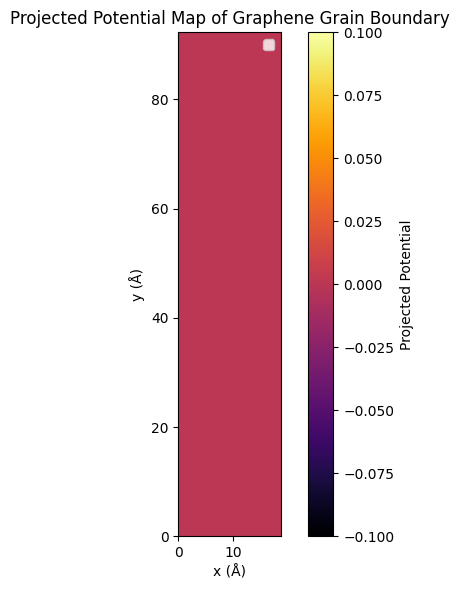

In [ ]:
# =========================================================================
# STEP 3: CALCULATING PROJECTED POTENTIAL Vp(x, y) FOR GRAPHENE GB
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
import numpy as np

# 1. Create ASE Atoms 

atoms_ase = Atoms(symbols='C' * len(atoms), positions=atoms)
coords = atoms_ase.get_positions()

xmin, ymin = coords[:,0].min(), coords[:,1].min()
xmax, ymax = coords[:,0].max(), coords[:,1].max()

Sx = xmax - xmin
Sy = ymax - ymin

print(f"ASE read {len(atoms_ase)} atoms")

# --- 3.1: Professional Atomic Potential Parameters ---
# Kirkland's parameters for Carbon (Z=6). 
# This provides a more realistic electrostatic field than a simple fixed width.
# V(r) = sum( a_i * exp(-b_i * k^2) ) in scattering factor terms.
a_kirk = [0.212080767, 0.199811865, 0.168254385]
b_kirk = [0.208605417, 0.208610186, 5.57870773]


def kirkland_potential_2d(r2):
    """Calculates the 2D projected potential for a Carbon atom at distance squared r2."""
    # Physics: Based on the analytic Fourier transform of the scattering factors.
    # V_proj(r) = 2 * pi^2 * sum( a_i / b_i * exp(-r^2 * pi^2 / b_i) ) -> simplified form:
    pot = 0
    for i in range(3):
        # Constants from Kirkland's "Advanced Computing in Electron Microscopy"
        pot += (a_kirk[i]) * np.exp(-r2 * (np.pi**2) / b_kirk[i])
    return pot * 2 * (np.pi**2)

# --- 3.2: Potential Map Calculation ---
# --- 3.2: Potential Map Calculation (No PBC Version) ---
def calculate_graphene_potential_no_pbc(atoms_obj, Sx, Sy, Nx, Ny):

    coords = atoms_obj.get_positions()
    
    V = np.zeros((Ny, Nx)) # (y, x) 矩阵
    dx = Sx / Nx
    dy = Sy / Ny

    print(f"Generating potential for {len(coords)} atoms (No PBC)...")

    for i, pos in enumerate(coords):
        ax, ay = pos[0], pos[1] 
        
        
        cutoff = 3.0
        
        ix_min = max(0, int((ax - cutoff) / dx))
        ix_max = min(Nx, int((ax + cutoff) / dx))
        iy_min = max(0, int((ay - cutoff) / dy))
        iy_max = min(Ny, int((ay + cutoff) / dy))

        
        for iy in range(iy_min, iy_max):
            for ix in range(ix_min, ix_max):
                
                px = ix * dx
                py = iy * dy
                
                
                r2 = (px - ax)**2 + (py - ay)**2
                
                if r2 < cutoff**2:
                    V[iy, ix] += kirkland_potential_2d(r2)
        
        if (i+1) % 500 == 0:
            print(f"Processed {i+1} atoms...")

    return V


V_graphene = calculate_graphene_potential_no_pbc(atoms_ase, Sx, Sy, Nx, Ny)

# --- 3.3: Full-Field Visualization ---
# =========================================================================
# STEP 4: VISUALIZE TOTAL PROJECTED POTENTIAL
# =========================================================================

plt.figure(figsize=(6,6))

extent = [0, Sx, 0, Sy]  # physical coordinates

plt.imshow(V_graphene,
           origin='lower',
           extent=extent,
           cmap='inferno')

plt.colorbar(label="Projected Potential")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.title("Projected Potential Map of Graphene Grain Boundary")


plt.legend()
plt.tight_layout()
plt.show()

## 4. Multislice Propagation Loop

Propagate the electron wave through the specimen.
*   Initial state: Plane wave.
*   Loop: For each slice layer (1 and 2), apply Transmission ($e^{i \sigma V}$) and Propagation ($P(k)$).


Starting Multislice propagation through Graphene Layer...
Simulation complete.


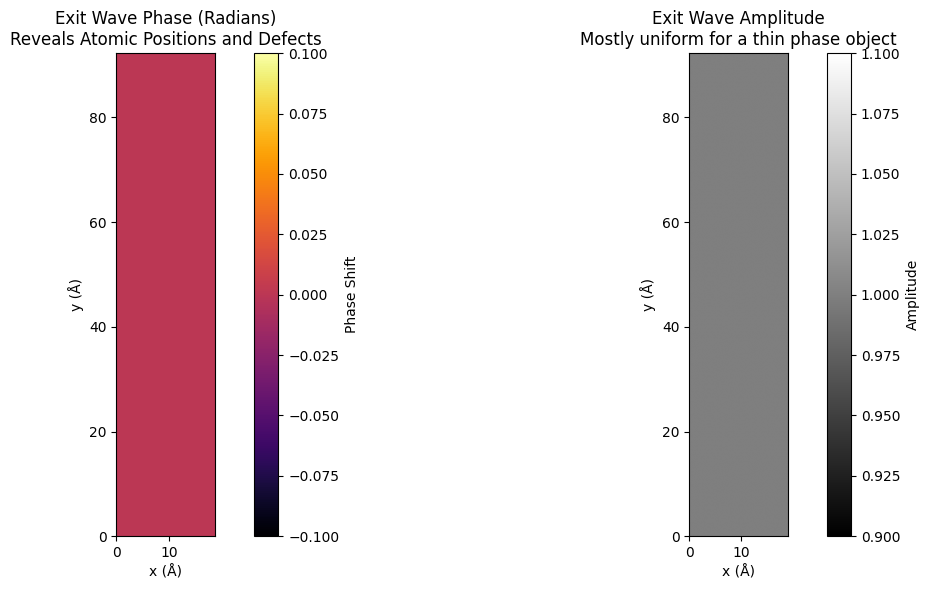

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# 4.1: Frequency Grid and Fresnel Propagator
# =========================================================================
# nx, ny: number of pixels
# Sx, Sy: supercell dimensions in Angstroms
# lam: electron wavelength (determined by kV)

# Standard numpy fftfreq gives frequencies in cycles/unit_length (1/Angstrom)
kx = np.fft.fftfreq(Nx, d=Sx/Nx)
ky = np.fft.fftfreq(Ny, d=Sy/Ny)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2  # Squared spatial frequency
# Fresnel Propagator: P(k) = exp(-i * pi * lambda * dz * k^2)
# For a single layer of graphene, dz is the effective "slice thickness".
# Usually, we use the interlayer spacing of graphite (approx 3.35 A) 
# to represent the volume a single layer occupies in the beam path.
dz_slice = 0.2 
propagator = np.exp(-1j * np.pi * lam * dz_slice * K2)

# =========================================================================
# 4.2: Transmission Function (The Interaction)
# =========================================================================
# sigma: interaction parameter (depends on electron energy)
# V_graphene: the projected potential we calculated using Lobato parameters

# Transmission Function: T(r) = exp(i * sigma * V_proj(r))
# This represents the phase shift the electron wave picks up from the atoms.
transmission_function = np.exp(1j * sigma * V_graphene)

# =========================================================================
# 4.3: Multislice Execution
# =========================================================================
# Initial Condition: Plane wave (amplitude 1, phase 0)
psi = np.ones((Ny, Nx), dtype=complex)

# For a single layer of graphene, the beam:
# 1. Hits the potential (Transmission)
# 2. Propagates through the thickness of the slice (Propagation)

print("Starting Multislice propagation through Graphene Layer...")

# Step 1: Interaction with the atoms
psi = psi * transmission_function

# Step 2: Propagation through the effective slice thickness
# Move to Fourier space to apply propagation
Psi_k = np.fft.fft2(psi)
Psi_k *= propagator
psi = np.fft.ifft2(Psi_k)

exit_wave = psi
print("Simulation complete.")

# =========================================================================
# 4.4: Professional Visualization
# =========================================================================
plt.figure(figsize=(14, 6))

# Phase is the most important part of the exit wave for light atoms like Carbon
plt.subplot(1, 2, 1)
plt.imshow(np.angle(exit_wave), cmap='inferno', extent=[0, Sx, 0, Sy])
plt.title("Exit Wave Phase (Radians)\nReveals Atomic Positions and Defects")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label='Phase Shift')

# Amplitude reveals 'absorption' or scattering outside the aperture
plt.subplot(1, 2, 2)
plt.imshow(np.abs(exit_wave), cmap='gray', extent=[0, Sx, 0, Sy])
plt.title("Exit Wave Amplitude\nMostly uniform for a thin phase object")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.colorbar(label='Amplitude')

plt.tight_layout()
plt.show()

## 5. Simulate Defocus Series

Apply the Contrast Transfer Function (CTF) to the exit wave to simulate images at Scherzer defocus and other values.
Requires spherical aberration $C_s \approx 1.0$ mm (typical).

Scherzer Defocus: -24.52 Å
>>> Saved Scherzer image: thetam_47.2_thetal_13.5.png


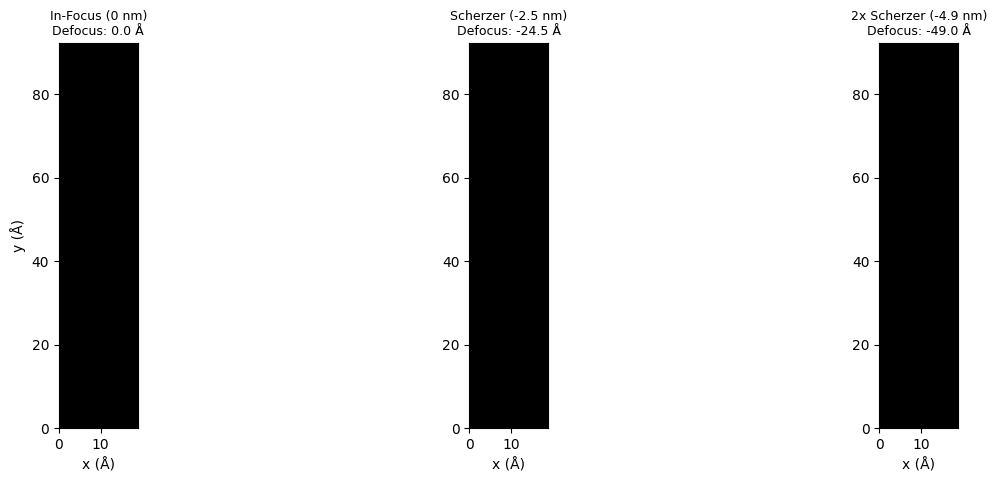

In [ ]:
# --- 4. Image Formation (CTF Application) ---

# The "Exit Wave" is what leaves the bottom of the sample.
# The microscope lenses (Objective Lens) modify this wave before it hits the camera.
# This modification is described by the Contrast Transfer Function (CTF).

# Microscope Aberrations
Cs_mm = 0.001  # Spherical Aberration [mm]
Cs = Cs_mm * 1e7 # Convert to Angstroms


# Defocus values to simulate
# Scherzer Defocus is a standard condition for optimal phase contrast.
# df_sch = -1.2 * sqrt(Cs * lambda)
df_scherzer = -1.2 * np.sqrt(Cs * lam)
print(f"Scherzer Defocus: {df_scherzer:.2f} Å")

defocus_list = [0, df_scherzer, 2 * df_scherzer]
names = ["In-Focus (0 nm)", f"Scherzer ({df_scherzer/10:.1f} nm)", f"2x Scherzer ({2*df_scherzer/10:.1f} nm)"]





plt.figure(figsize=(15, 5))

for i, df in enumerate(defocus_list):
    # Setup CTF in Fourier Space
    # Phase shift chi(k)
    # chi = pi * lambda * k^2 * df + (pi/2) * Cs * lambda^3 * k^4
    # Note: Sign conventions vary! Here assuming df < 0 is underfocus.
    
    # Term 1: Defocus
    term1 = np.pi * lam * K2 * df
    
    # Term 2: Spherical Aberration
    term2 = (np.pi / 2.0) * Cs * (lam**3) * (K2**2)
    
    CTF_phase = term1 + term2
    
    # The pupil function includes the Aperture (omitted here for high-res) and Phase
    Pupil = np.exp(-1j * CTF_phase)
    
    # Apply CTF to the wave in Fourier domain
    # 1. FFT the exit wave
    Image_wave_k = np.fft.fft2(exit_wave)
    
    # 2. Multiply by Pupil/CTF
    Image_wave_k *= Pupil
    
    # 3. IFFT back to real space
    Image_wave = np.fft.ifft2(Image_wave_k)
    
    # 4. Detect Intensity (Modulus Squared)
    Intensity = np.abs(Image_wave)**2
    
    # Plotting
    plt.subplot(1, 3, i+1)
    plt.imshow(Intensity, cmap='gray', extent=[0, Sx, 0, Sy])
    plt.title(f"{names[i]}\nDefocus: {df:.1f} Å", fontsize=9)
    plt.xlabel("x (Å)")
    if i == 0:
        plt.ylabel("y (Å)")
    
    if df == df_scherzer:
            
            save_name = f"thetam_{mis:.1f}_thetal_{angle:.1f}.png"
            
            plt.imsave(save_name, Intensity, cmap='gray')
            print(f">>> Saved Scherzer image: {save_name}")



plt.show()



# README: Graphene Grain Boundary Multislice Simulation

## 1. Prerequisites
Ensure the following Python libraries are installed in your environment:
* **NumPy**: Matrix operations and Fast Fourier Transforms (FFT).
* **Matplotlib**: Image visualization and PNG export.
* **Glob & OS**: File handling and path management.

## 2. Workflow

### Phase 1: Data Preparation
* **File Placement**: Move your `.xyz` files into the `/MultiSlice_final_experiment` or `//MultiSlice_final_simulation` directories.
* **Data Format**: 
* **Simulation**: 
    * **Line 1**: `misorientation` and `line_angle` (metadata).
    * **Line 2**: Box dimensions ($S_x, S_y, S_z$).
    * **Line 3+**: Atomic coordinates ($x, y, z$).
* **Experiment**: 
    * **Line 1**: Traces the origin of the data to an experimental .dm3 file (Gatan DigitalMicrograph format), likely a graphene (Gr) * * * **Line 2**: PixelSize (0.093734 Å): The critical resolution used for grid discretization.BoundaryLengthEstimate: The physical length of the grain boundary being analyzed.Coords in Å: Confirms that all spatial values are in Angstroms ($10^{-10}$ m).
    * **Line 3+**: Atomic coordinates ($x, y, z$).

* **Setup**: Update the `folder` path variable in the script to match your local directory.


### Phase 2: Physics & Grid Setup
* **Voltage**: Set to **80kV** by default (to prevent knock-on damage in graphene).
* **Sampling**: **0.05 Å/pixel**.
* **FFT Optimization**: Grid dimensions ($N_x, N_y$) are automatically adjusted to the nearest **Power of 2** (e.g., 512, 1024) to optimize computational speed.

### Phase 3: Multislice Calculation
1.  **Potential Projection**: Converts discrete atomic coordinates into a continuous 2D electrostatic potential map.
2.  **Propagation**: The electron wave "steps" through the sample, alternating between real-space phase shifts and Fourier-space transmission.

### Phase 4: Image Formation (CTF)
The script simulates the objective lens using the **Contrast Transfer Function (CTF)** formula:
$$\chi(k) = \pi \lambda \Delta f k^2 + \frac{\pi}{2} C_s \lambda^3 k^4$$

It generates a comparison plot for three defocus conditions:
* **In-Focus (0 Å)**: Pure phase contrast, usually appearing "flat."
* **Scherzer Defocus**: The "sweet spot" where spherical aberration and defocus cancel out to produce maximum structural contrast.
* **2x Scherzer**: Significant delocalization; used to observe oscillatory behavior.

## 3. Output & Export
* **Auto-Save**: The script detects the **Scherzer Defocus** iteration and saves it automatically.
* **Naming Convention**: `thetam_{mis}_thetal_{angle}.png` 
    * *Example*: `thetam_13.0_thetal_4.0.png`
* **Format**: Pure grayscale PNG using `plt.imsave`. This exports the raw intensity matrix without axes or labels, ideal for quantitative analysis.

